# TFG: Simulación de Balanceo de Cargas Edge/Quantum

In [1]:
%load_ext autoreload
%autoreload 2

import json
import time
import networkx as nx
import matplotlib.pyplot as plt
from src.generador_red import generar_red
from src.solver_voraz import solver_voraz
from src.solver_exacto import solver_exacto
from src.solver_cuantico import solver_cuantico
from src.gestor_redes import guardar_red, cargar_red
from src.visualizador import dibujar_asignaciones


In [2]:

#CONFIGURAMOS EL EXPERIMENTO (ESCENARIO GRANDE: comparativa Voraz vs Exacto)
SEED_GRANDE = 42
NUM_SERVIDORES = 6
NUM_USUARIOS = 30
CAPACIDAD_MAX_SERVIDOR = 12
RADIO_COBERTURA = 60 # km (Solo se conectan si están a menos de esta distancia)

#Generar la red (semilla fija para que el escenario sea reproducible)
mi_grafo, mis_servidores, mis_usuarios = generar_red(
    num_serv=NUM_SERVIDORES,
    num_usr=NUM_USUARIOS,
    capacidad_max=CAPACIDAD_MAX_SERVIDOR,
    radio_cobertura=RADIO_COBERTURA,
    seed=SEED_GRANDE
)

print(f"Red generada: {len(mis_servidores)} servidores, {len(mis_usuarios)} usuarios, {mi_grafo.number_of_edges()} conexiones posibles.")


Red generada: 6 servidores, 30 usuarios, 96 conexiones posibles.


In [3]:
# Guardamos la topología del escenario grande en disco para que el experimento sea reproducible
guardar_red(mi_grafo, mis_servidores, mis_usuarios, 'data/red_grande_6s_30u.json')


✅ Red guardada exitosamente en: data/red_grande_6s_30u.json


In [4]:
# [OPCIONAL] Recargar la red guardada en vez de regenerarla (útil para repetir el experimento exactamente igual)
# Descomenta las líneas de abajo para sobrescribir la red generada arriba con la guardada en disco
# mi_grafo, mis_servidores, mis_usuarios = cargar_red('data/red_grande_6s_30u.json')
# nx.draw(mi_grafo, pos=nx.get_node_attributes(mi_grafo, 'pos'), with_labels=True, node_color='lightgreen')


Iniciamos algoritmo voraz:
 Servidor_0 (Ocupación recursos: 12/12): Usuario_0 (14ms, dem: 3), Usuario_1 (18ms, dem: 1), Usuario_4 (14ms, dem: 3), Usuario_7 (14ms, dem: 1), Usuario_13 (14ms, dem: 1), Usuario_16 (16ms, dem: 3)
 Servidor_1 (Ocupación recursos: 5/12): Usuario_18 (17ms, dem: 1), Usuario_19 (9ms, dem: 1), Usuario_25 (23ms, dem: 3)
 Servidor_2 (Ocupación recursos: 12/12): Usuario_6 (11ms, dem: 2), Usuario_9 (16ms, dem: 2), Usuario_12 (15ms, dem: 2), Usuario_15 (17ms, dem: 1), Usuario_22 (13ms, dem: 3), Usuario_29 (17ms, dem: 2)
 Servidor_3 (Ocupación recursos: 12/12): Usuario_2 (10ms, dem: 1), Usuario_10 (12ms, dem: 2), Usuario_11 (10ms, dem: 2), Usuario_21 (6ms, dem: 2), Usuario_23 (10ms, dem: 2), Usuario_24 (8ms, dem: 3)
 Servidor_4 (Ocupación recursos: 11/12): Usuario_8 (4ms, dem: 3), Usuario_17 (24ms, dem: 3), Usuario_20 (18ms, dem: 1), Usuario_26 (11ms, dem: 3), Usuario_28 (9ms, dem: 1)
 Servidor_5 (Ocupación recursos: 7/12): Usuario_3 (14ms, dem: 1), Usuario_5 (9ms, dem

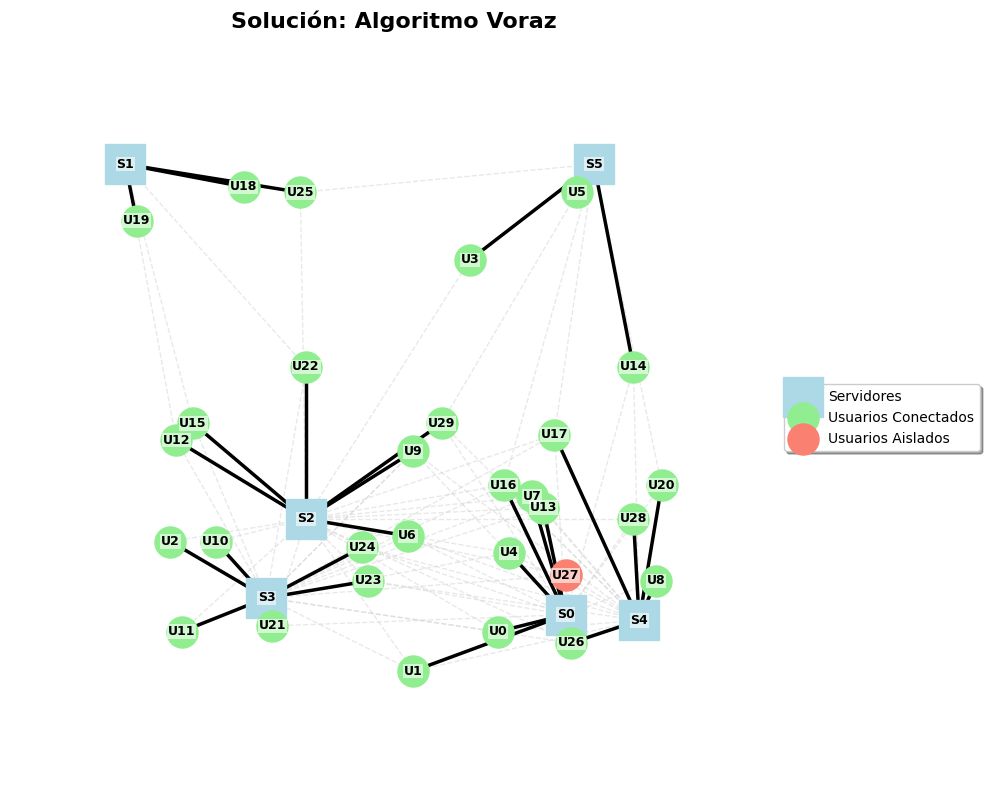

In [5]:
#Resolver con algoritmo voraz
t0 = time.perf_counter()
asignaciones_voraz, latencia_voraz = solver_voraz(mi_grafo, mis_servidores, mis_usuarios)
tiempo_voraz = time.perf_counter() - t0

dibujar_asignaciones(mi_grafo, asignaciones_voraz, mis_servidores, mis_usuarios, 'Solución: Algoritmo Voraz')


Iniciamos algoritmo exacto (PuLP):
 Servidor_0 (Ocupación recursos: 12/12): Usuario_1 (18ms, dem: 1), Usuario_7 (14ms, dem: 1), Usuario_13 (14ms, dem: 1), Usuario_16 (16ms, dem: 3), Usuario_26 (6ms, dem: 3), Usuario_27 (5ms, dem: 3)
 Servidor_1 (Ocupación recursos: 5/12): Usuario_18 (17ms, dem: 1), Usuario_19 (9ms, dem: 1), Usuario_25 (23ms, dem: 3)
 Servidor_2 (Ocupación recursos: 12/12): Usuario_6 (11ms, dem: 2), Usuario_9 (16ms, dem: 2), Usuario_12 (15ms, dem: 2), Usuario_15 (17ms, dem: 1), Usuario_22 (13ms, dem: 3), Usuario_29 (17ms, dem: 2)
 Servidor_3 (Ocupación recursos: 12/12): Usuario_2 (10ms, dem: 1), Usuario_10 (12ms, dem: 2), Usuario_11 (10ms, dem: 2), Usuario_21 (6ms, dem: 2), Usuario_23 (10ms, dem: 2), Usuario_24 (8ms, dem: 3)
 Servidor_4 (Ocupación recursos: 11/12): Usuario_0 (17ms, dem: 3), Usuario_4 (15ms, dem: 3), Usuario_8 (4ms, dem: 3), Usuario_20 (18ms, dem: 1), Usuario_28 (9ms, dem: 1)
 Servidor_5 (Ocupación recursos: 10/12): Usuario_3 (14ms, dem: 1), Usuario_5 (9

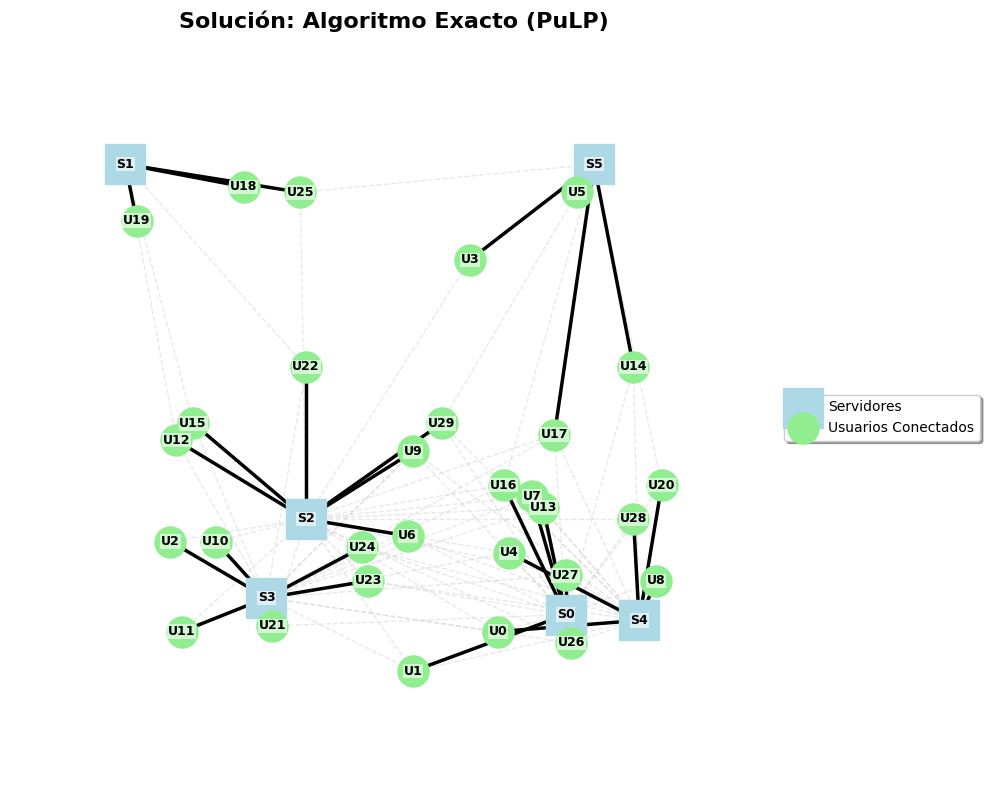

In [6]:
#Solución con algoritmo exacto (uso de PuLP)
t0 = time.perf_counter()
asignaciones_exacto, latencia_exacto = solver_exacto(mi_grafo, mis_servidores, mis_usuarios)
tiempo_exacto = time.perf_counter() - t0

dibujar_asignaciones(mi_grafo, asignaciones_exacto, mis_servidores, mis_usuarios, 'Solución: Algoritmo Exacto (PuLP)')


## Escenario reducido para el solver cuántico (QAOA)

El número de qubits simulados crece muy rápido con el tamaño de la red: a los `usuarios × servidores_alcanzables + usuarios` qubits base hay que sumarles las variables de holgura que `MinimumEigenOptimizer` añade para convertir la restricción de capacidad (`<=`) en una igualdad. Con el escenario grande (6 servidores / 30 usuarios) el número real de qubits simulados supera con creces el límite práctico de un simulador de vectores de estado en un portátil.

Por eso el solver cuántico se prueba aquí sobre una red **reducida e independiente** (no reutiliza `mi_grafo`), con 1 servidor y 2 usuarios (~7 qubits tras las variables de holgura). Su resultado no es directamente comparable en tamaño con las ejecuciones de Voraz/Exacto de arriba, así que Voraz y Exacto se vuelven a ejecutar también sobre esta misma red reducida para tener una comparación de calidad de solución en igualdad de condiciones (aunque a pequeña escala).

**Nota empírica (relevante para el capítulo de Resultados):** durante las pruebas, un escenario de solo 2 servidores / 2 usuarios (~10 qubits) ya tardó más de 15 minutos sin converger con `COBYLA(maxiter=300)`, frente a los ~28 segundos que tarda esta configuración de ~7 qubits. El salto de tiempo no es solo por el mayor tamaño del vector de estado (2^n), sino porque con más qubits COBYLA deja de converger pronto y agota las 300 iteraciones, cada una más cara de simular. Esto refuerza la idea de usar el "muro exponencial" como resultado en sí mismo (ver `historial_conversacion.md`) en vez de intentar escalar el cuántico al tamaño del escenario clásico.


In [7]:
#CONFIGURAMOS EL EXPERIMENTO (ESCENARIO REDUCIDO: apto para simular QAOA)
SEED_REDUCIDA = 7
NUM_SERVIDORES_R = 1
NUM_USUARIOS_R = 2
CAPACIDAD_MAX_SERVIDOR_R = 5
RADIO_COBERTURA_R = 100  # km (radio amplio para que la red reducida quede totalmente conectada)

grafo_reducido, servidores_reducido, usuarios_reducido = generar_red(
    num_serv=NUM_SERVIDORES_R,
    num_usr=NUM_USUARIOS_R,
    capacidad_max=CAPACIDAD_MAX_SERVIDOR_R,
    radio_cobertura=RADIO_COBERTURA_R,
    seed=SEED_REDUCIDA
)

print(f"Red reducida generada: {len(servidores_reducido)} servidores, {len(usuarios_reducido)} usuarios, {grafo_reducido.number_of_edges()} conexiones posibles.")

# Guardamos también esta topología reducida para que el experimento cuántico sea reproducible
guardar_red(grafo_reducido, servidores_reducido, usuarios_reducido, 'data/red_reducida_1s_2u.json')


Red reducida generada: 1 servidores, 2 usuarios, 2 conexiones posibles.
✅ Red guardada exitosamente en: data/red_reducida_1s_2u.json


Iniciamos algoritmo voraz:
 Servidor_0 (Ocupación recursos: 2/5): Usuario_0 (35ms, dem: 1), Usuario_1 (28ms, dem: 1)

 Latencia total de la red (Voraz): 63 ms


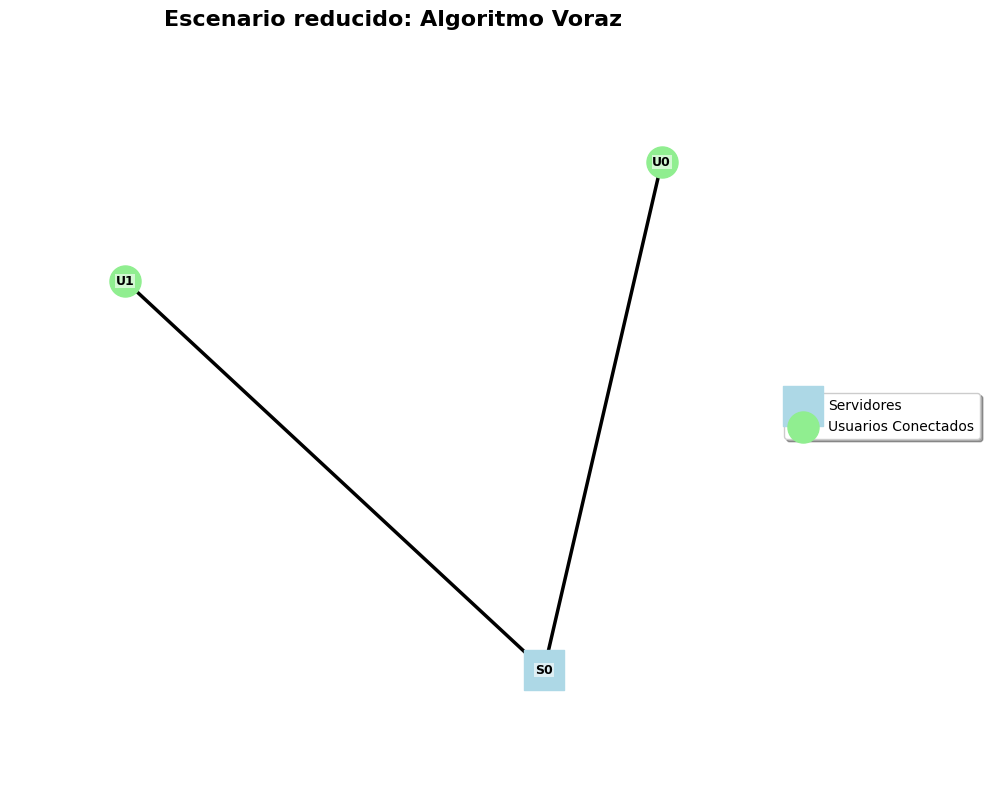

Iniciamos algoritmo exacto (PuLP):
 Servidor_0 (Ocupación recursos: 2/5): Usuario_0 (35ms, dem: 1), Usuario_1 (28ms, dem: 1)

 Latencia total de la red (Exacto): 63 ms


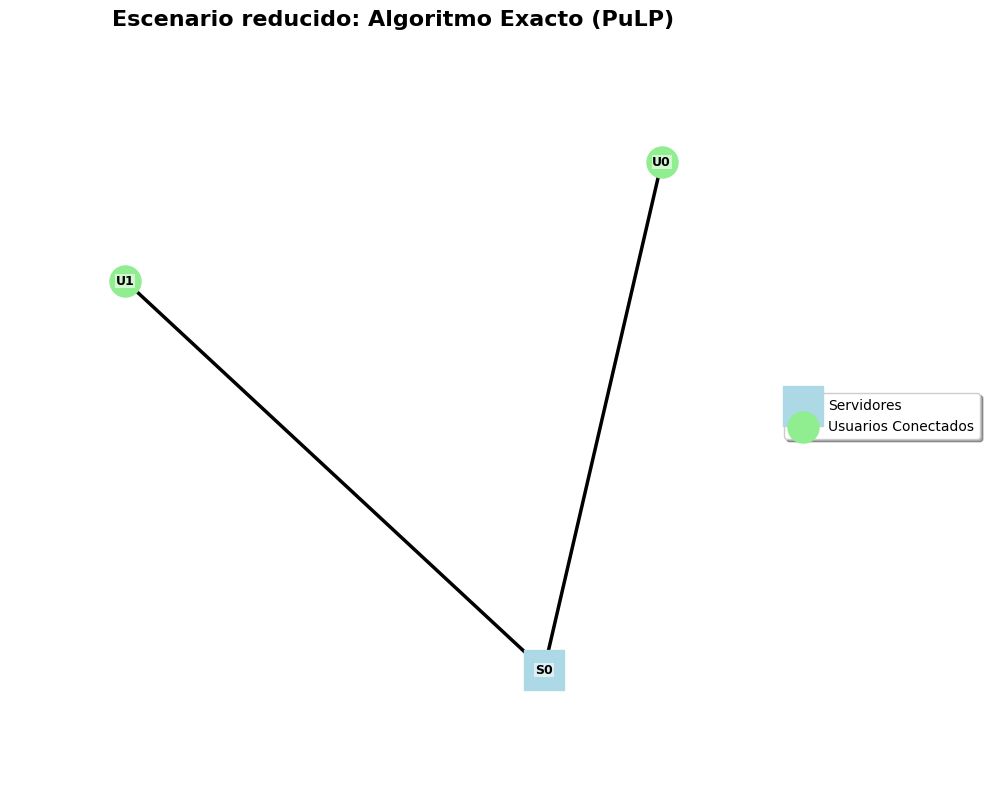

Iniciamos algoritmo cuántico (QAOA con Qiskit):
 -> Construyendo QUBO con 4 variables cuánticas (qubits base).
 -> Configurando Optimizador QAOA y Sampler V2...
 -> Ejecutando simulación cuántica (esto puede tardar unos minutos)...


Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 36   Least value of F = -5410.7744140625
The corresponding X is:
[ 5.48002017  2.27616515 -3.62873983  2.71809801]



 -> Simulación finalizada en 31.88 segundos.
 Servidor_0 (Ocupación recursos: 2/5): Usuario_0 (35ms, dem: 1), Usuario_1 (28ms, dem: 1)

 Latencia total de la red (Cuántico QAOA): 63 ms
------------------------------------------


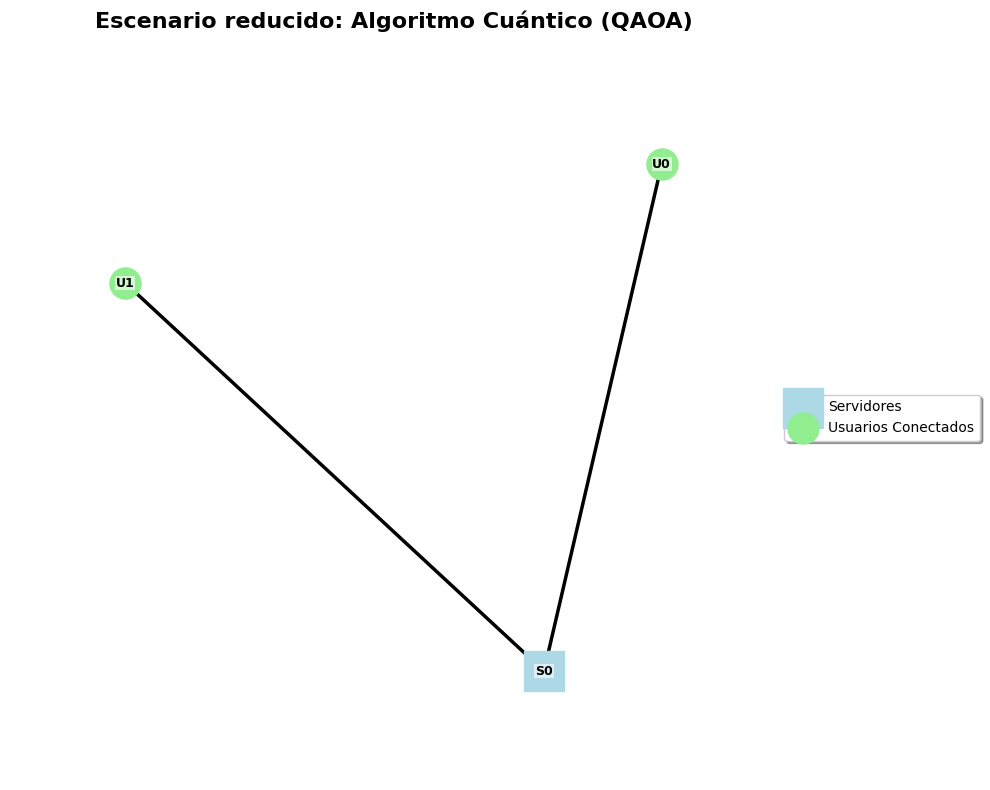

In [8]:
#Comparativa de los tres algoritmos sobre la red reducida

t0 = time.perf_counter()
asignaciones_voraz_r, latencia_voraz_r = solver_voraz(grafo_reducido, servidores_reducido, usuarios_reducido)
tiempo_voraz_r = time.perf_counter() - t0
dibujar_asignaciones(grafo_reducido, asignaciones_voraz_r, servidores_reducido, usuarios_reducido, 'Escenario reducido: Algoritmo Voraz')

t0 = time.perf_counter()
asignaciones_exacto_r, latencia_exacto_r = solver_exacto(grafo_reducido, servidores_reducido, usuarios_reducido)
tiempo_exacto_r = time.perf_counter() - t0
dibujar_asignaciones(grafo_reducido, asignaciones_exacto_r, servidores_reducido, usuarios_reducido, 'Escenario reducido: Algoritmo Exacto (PuLP)')

t0 = time.perf_counter()
asignaciones_cuantico_r, latencia_cuantico_r = solver_cuantico(grafo_reducido, servidores_reducido, usuarios_reducido)
tiempo_cuantico_r = time.perf_counter() - t0
dibujar_asignaciones(grafo_reducido, asignaciones_cuantico_r, servidores_reducido, usuarios_reducido, 'Escenario reducido: Algoritmo Cuántico (QAOA)')


## Guardar resultados para la memoria

Consolidamos las métricas (latencia total, tiempo de ejecución, usuarios asignados) de ambos escenarios en un único JSON reproducible en `data/`, para poder citarlas directamente en el capítulo de Implementación y Resultados sin tener que volver a ejecutar el notebook.

In [9]:
resultados = {
    "escenario_grande": {
        "num_servidores": NUM_SERVIDORES,
        "num_usuarios": NUM_USUARIOS,
        "capacidad_max": CAPACIDAD_MAX_SERVIDOR,
        "radio_cobertura": RADIO_COBERTURA,
        "seed": SEED_GRANDE,
        "voraz": {"latencia_total": latencia_voraz, "tiempo_s": tiempo_voraz, "usuarios_asignados": len(asignaciones_voraz)},
        "exacto": {"latencia_total": latencia_exacto, "tiempo_s": tiempo_exacto, "usuarios_asignados": len(asignaciones_exacto)},
    },
    "escenario_reducido": {
        "num_servidores": NUM_SERVIDORES_R,
        "num_usuarios": NUM_USUARIOS_R,
        "capacidad_max": CAPACIDAD_MAX_SERVIDOR_R,
        "radio_cobertura": RADIO_COBERTURA_R,
        "seed": SEED_REDUCIDA,
        "voraz": {"latencia_total": latencia_voraz_r, "tiempo_s": tiempo_voraz_r, "usuarios_asignados": len(asignaciones_voraz_r)},
        "exacto": {"latencia_total": latencia_exacto_r, "tiempo_s": tiempo_exacto_r, "usuarios_asignados": len(asignaciones_exacto_r)},
        "cuantico": {"latencia_total": latencia_cuantico_r, "tiempo_s": tiempo_cuantico_r, "usuarios_asignados": len(asignaciones_cuantico_r)},
    },
}

with open('data/resultados_experimento.json', 'w', encoding='utf-8') as f:
    json.dump(resultados, f, indent=4, ensure_ascii=False)

print("Resultados guardados en data/resultados_experimento.json")
resultados


Resultados guardados en data/resultados_experimento.json


{'escenario_grande': {'num_servidores': 6,
  'num_usuarios': 30,
  'capacidad_max': 12,
  'radio_cobertura': 60,
  'seed': 42,
  'voraz': {'latencia_total': 1395,
   'tiempo_s': 0.0004817000008188188,
   'usuarios_asignados': 29},
  'exacto': {'latencia_total': 400,
   'tiempo_s': 0.036863000000266766,
   'usuarios_asignados': 30}},
 'escenario_reducido': {'num_servidores': 1,
  'num_usuarios': 2,
  'capacidad_max': 5,
  'radio_cobertura': 100,
  'seed': 7,
  'voraz': {'latencia_total': 63,
   'tiempo_s': 0.0003507000001263805,
   'usuarios_asignados': 2},
  'exacto': {'latencia_total': 63,
   'tiempo_s': 0.013282599999911326,
   'usuarios_asignados': 2},
  'cuantico': {'latencia_total': 63,
   'tiempo_s': 31.883992000000035,
   'usuarios_asignados': 2}}}

## Benchmark de escalabilidad ("muro exponencial")

Medimos cómo escalan tiempo de ejecución y calidad de la solución con el tamaño de la red, usando `ejecutar_benchmark_escalabilidad()` de `src/benchmark.py`. Se lanzan dos experimentos con configuraciones distintas (no son la continuación uno del otro, así que el salto entre ambos en las gráficas no es comparable directamente):

- **Rango amplio** (Voraz vs Exacto): de 15 a 600 usuarios. El número de servidores **escala junto con los usuarios** manteniendo la misma proporción que el escenario grande (6 servidores / 30 usuarios ≈ 1 servidor cada 5 usuarios). El solver cuántico se salta automáticamente en todo este rango porque supera el límite de 20 qubits base.
- **Rango reducido y seguro para el cuántico**: 1 servidor, capacidad 5, radio 100 (sin cambios respecto a antes).

**Corrección de un sesgo de densidad (mapa fijo 100×100):** al escalar servidores y usuarios manteniendo el mapa fijo en 100×100 (`lado_area` por defecto de `generar_red`), la *cantidad absoluta* de servidores al alcance de cada usuario (`radio_cobertura=60` fijo) crecía sin control con el tamaño de la red — de una media de ~2 servidores alcanzables con 15 usuarios a ~73 con 600 usuarios — porque meter más y más servidores en la misma área fija los apelotona dentro del radio de cobertura de cualquier usuario. Eso hacía el problema artificialmente más fácil para el voraz al crecer la red (más opciones entre las que elegir), justo el efecto contrario al que se quiere medir.

La corrección **no** toca `radio_cobertura` (se mantiene fijo en 60, como pide el enunciado del problema — es una propiedad de la tecnología de red, no de la red que se genera). En su lugar, `generar_red()` gana un parámetro opcional `lado_area` (por defecto 100, igual que antes — comportamiento 100% compatible con las redes pequeñas ya guardadas en `data/`) y el benchmark escala el lado del mapa junto con el número de servidores para mantener constante la **densidad de servidores por área** (`lado_area(tamanio) = 100·√(servidores(tamanio)/6)`, usando como referencia los 6 servidores en 100×100 del escenario grande). Verificado con 5 repeticiones por tamaño: la media de servidores alcanzables por usuario en valor absoluto pasa de **2.9 (15 usuarios) a 6.0 (600 usuarios)** con la corrección, frente a los 2.2 → 72.7 de antes — queda un crecimiento residual leve porque en mapas pequeños el radio de 60 cubre proporcionalmente más área que en mapas grandes (efecto de borde que se atenúa según crece el mapa), pero ya no hay una explosión artificial de opciones.

**El punto de "muro" del exacto se recalibró de cero (no se asumió que seguía en 500-600 usuarios)** y el resultado fue sorprendente: con grafos mucho más dispersos (cada usuario ve del orden de 3-6 servidores en vez de hasta 73), el MILP resulta *más* rápido en la práctica, no más lento — menos alternativas entre las que repartir la carga generalmente significa un árbol de búsqueda más pequeño. Una prueba aislada con una semilla concreta sí encontró instancias que se bloqueaban más allá de ~335 usuarios (igual de errático e instancia-dependiente que en el benchmark anterior), pero en la ejecución real con 5 repeticiones por tamaño y las semillas deterministas del benchmark, el exacto **no llegó a superar el timeout de 60s de forma sistemática en ningún tamaño del rango 15-600** — solo 2 de las 85 ejecuciones individuales de exacto superaron el timeout (tamaño 150 y 525, una repetición cada una), compensadas por las otras 4 repeticiones de ese mismo tamaño en la media. El tiempo medio del exacto se mantiene entre ~0.1s y ~22s en todo el rango, muy lejos del timeout — el "muro" con la densidad corregida queda fuera de este rango de tamaños, no dentro de él como antes.

Las repeticiones por tamaño suben de 3 a 5 (antes bastaba con 3, pero con la paralelización el coste extra es asumible y 5 repeticiones dan una media más estable, sobre todo para promediar sobre los timeouts puntuales y errático que sí aparecen).

Los resultados agregados se guardan en `data/benchmark_escalabilidad.csv`.


In [10]:
import math
import time as _time
import pandas as pd
from src.benchmark import ejecutar_benchmark_escalabilidad

# Rango amplio: Voraz vs Exacto, con el número de servidores Y el lado del mapa escalando
# junto con los usuarios. Los servidores mantienen la misma proporción que el escenario
# grande (~1 servidor cada 5 usuarios); el mapa escala para mantener constante la densidad
# de servidores por área (misma densidad que 6 servidores en un mapa de 100x100), evitando
# que radio_cobertura=60 (fijo) alcance una fracción creciente de servidores según se
# apelotonan en un área fija. El cuántico se salta solo (supera 20 qubits base en todo este rango).
TAMANIOS_AMPLIO = [15, 30, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 525, 550, 575, 600]

def _num_servidores(n):
    return max(1, round(n / 5))

def _lado_area(n):
    return 100 * math.sqrt(_num_servidores(n) / 6)

t0_benchmark = _time.perf_counter()

benchmark_amplio = ejecutar_benchmark_escalabilidad(
    tamanios_usuarios=TAMANIOS_AMPLIO,
    num_servidores=_num_servidores,
    capacidad_max=CAPACIDAD_MAX_SERVIDOR,
    radio_cobertura=RADIO_COBERTURA,
    lado_area=_lado_area,
    repeticiones=5,
    timeout_s=60,
)

# Rango reducido y seguro para el cuántico (ajustado a 1-2 usuarios tras la prueba aislada;
# mapa por defecto 100x100, no aplica la corrección de densidad porque no forma parte del
# barrido de escalabilidad)
benchmark_reducido = ejecutar_benchmark_escalabilidad(
    tamanios_usuarios=[1, 2],
    num_servidores=1,
    capacidad_max=5,
    radio_cobertura=100,
    repeticiones=5,
)

tiempo_total_benchmark = _time.perf_counter() - t0_benchmark

benchmark_df = pd.concat([benchmark_amplio, benchmark_reducido], ignore_index=True)
benchmark_df.to_csv('data/benchmark_escalabilidad.csv', index=False)

print(f"Benchmark guardado en data/benchmark_escalabilidad.csv ({len(benchmark_df)} filas).")
print(f"Tiempo total del benchmark (con paralelización): {tiempo_total_benchmark:.1f} s")
benchmark_df


[benchmark] exacto (tamanio=150, seed=15002) superó el timeout de 60s -> NaN


[benchmark] exacto (tamanio=525, seed=52500) superó el timeout de 60s -> NaN


Benchmark guardado en data/benchmark_escalabilidad.csv (57 filas).
Tiempo total del benchmark (con paralelización): 131.9 s


,tamanio,num_servidores,solver,tiempo_medio_s,latencia_media,usuarios_sin_asignar_media,num_qubits_estimado
0,15,3,voraz,0.000231,216.6,0.00,58.4
1,15,3,exacto,0.058061,206.6,0.00,58.4
2,15,3,cuantico,NaN,NaN,NaN,58.4
3,30,6,voraz,0.000395,1637.8,1.20,131.6
4,30,6,exacto,0.101867,455.2,0.00,131.6
5,30,6,cuantico,NaN,NaN,NaN,131.6
6,50,10,voraz,0.000625,2697.4,2.00,276.8
7,50,10,exacto,0.143497,746.0,0.00,276.8
8,50,10,cuantico,NaN,NaN,NaN,276.8
9,75,15,voraz,0.000937,4491.2,3.40,434.4


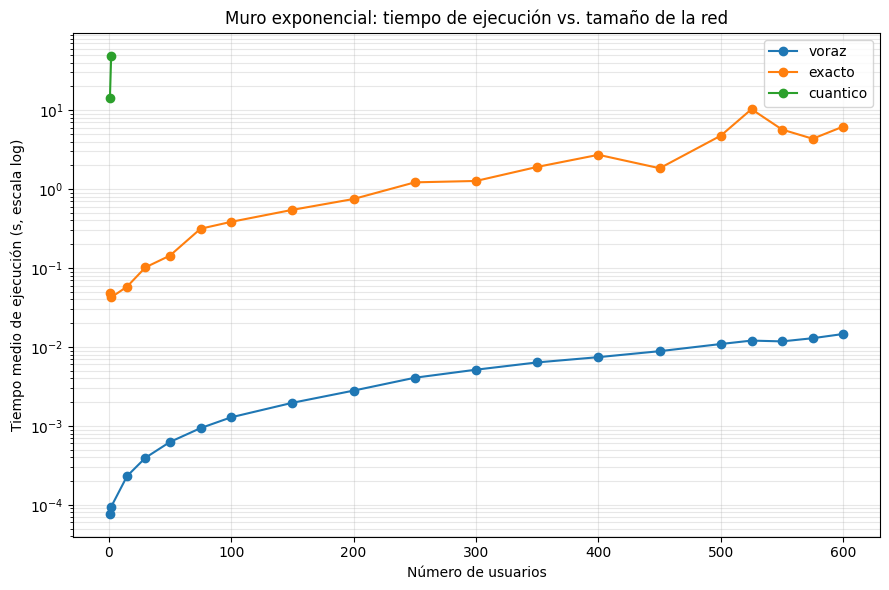

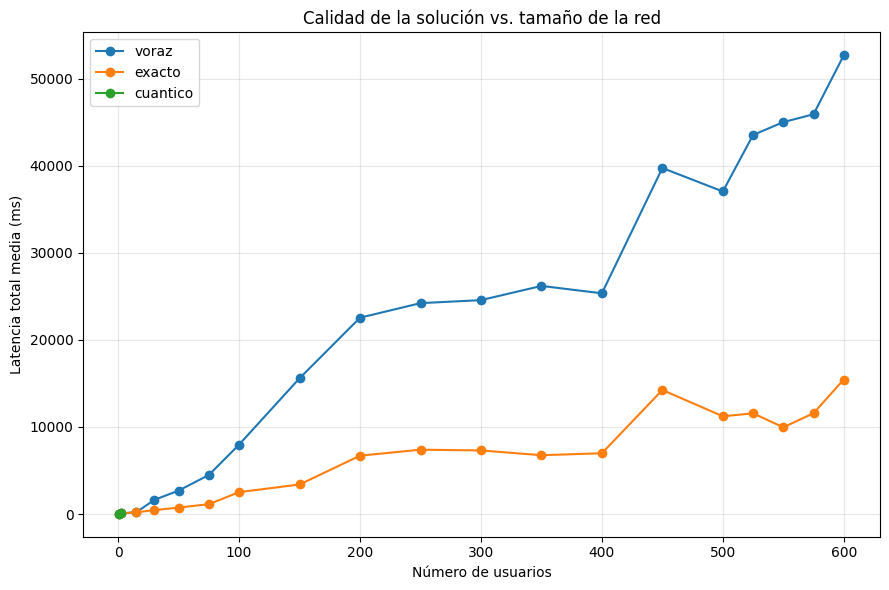

In [11]:
#Gráfica (a): tiempo de ejecución (escala log) vs. tamaño — el "muro exponencial"
fig, ax = plt.subplots(figsize=(9, 6))
for solver in ['voraz', 'exacto', 'cuantico']:
    datos = benchmark_df[benchmark_df['solver'] == solver].dropna(subset=['tiempo_medio_s']).sort_values('tamanio')
    if not datos.empty:
        ax.plot(datos['tamanio'], datos['tiempo_medio_s'], marker='o', label=solver)

ax.set_yscale('log')
ax.set_xlabel('Número de usuarios')
ax.set_ylabel('Tiempo medio de ejecución (s, escala log)')
ax.set_title('Muro exponencial: tiempo de ejecución vs. tamaño de la red')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig('data/muro_exponencial_tiempo.png', dpi=150)
plt.show()

#Gráfica (b): latencia media (calidad de la solución) vs. tamaño
fig2, ax2 = plt.subplots(figsize=(9, 6))
for solver in ['voraz', 'exacto', 'cuantico']:
    datos = benchmark_df[benchmark_df['solver'] == solver].dropna(subset=['latencia_media']).sort_values('tamanio')
    if not datos.empty:
        ax2.plot(datos['tamanio'], datos['latencia_media'], marker='o', label=solver)

ax2.set_xlabel('Número de usuarios')
ax2.set_ylabel('Latencia total media (ms)')
ax2.set_title('Calidad de la solución vs. tamaño de la red')
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig('data/muro_exponencial_calidad.png', dpi=150)
plt.show()


## Coste total: ¿cuándo deja de compensar el exacto?

Las dos gráficas anteriores muestran el tiempo y la latencia por separado, pero no responden directamente a la pregunta que interesa para la memoria: si el exacto tarda más en calcular pero encuentra una solución mejor, **¿a partir de qué tamaño de red ese tiempo de más dejar de compensar la mejora en latencia?**

Para verlo en una sola gráfica, definimos un "coste total" muy simplificado que suma, en las mismas unidades (milisegundos), el tiempo de cómputo y la latencia de red de la solución encontrada:

```
coste_total_ms = (tiempo_medio_s × 1000) + latencia_media_ms
```

Es una simplificación deliberada: trata 1 ms de espera por el cálculo como si fuera exactamente equivalente a 1 ms de latencia de red sufrida por los usuarios, lo cual no es necesariamente cierto en un despliegue real (el tiempo de cómputo se paga una vez al planificar; la latencia se sufre de forma continua mientras dura la asignación). Aun así, sirve como indicador de tendencia: mientras el exacto sea rápido, su mejor latencia domina y su coste total es igual o menor que el del voraz; en cuanto el tiempo de cómputo empieza a crecer sin control (el "muro exponencial" de la gráfica (a)), ese término acaba dominando la suma y el coste total del exacto supera al del voraz aunque su latencia siga siendo mejor.

Esta comparación solo tiene sentido entre voraz y exacto —el cuántico no tiene un rango de tamaños comparable, así que no entra en esta gráfica— y usa el mismo rango ampliado (15 a 600 usuarios) del benchmark anterior.


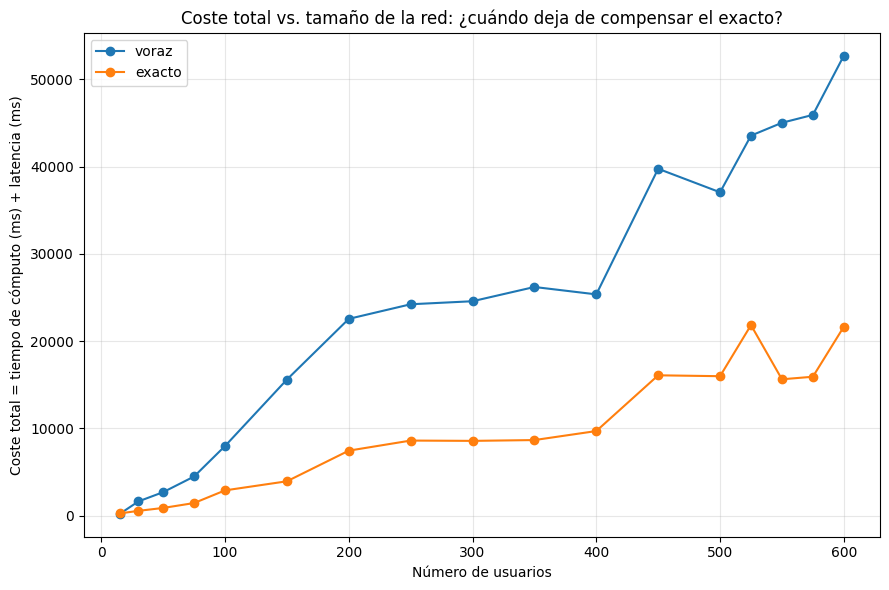

No se detectó un punto de cruce claro en los datos disponibles.


In [12]:
#Gráfica (c): coste total (tiempo de cómputo + latencia, ambos en ms) vs. tamaño

coste_df = benchmark_amplio[benchmark_amplio['solver'].isin(['voraz', 'exacto'])].copy()
coste_df['coste_total_ms'] = coste_df['tiempo_medio_s'] * 1000 + coste_df['latencia_media']
coste_df = coste_df.dropna(subset=['coste_total_ms']).sort_values('tamanio')

voraz_c = coste_df[coste_df['solver'] == 'voraz'].set_index('tamanio')['coste_total_ms']
exacto_c = coste_df[coste_df['solver'] == 'exacto'].set_index('tamanio')['coste_total_ms']
tamanios_comunes = sorted(set(voraz_c.index) & set(exacto_c.index))

# Punto de cruce: primer tamaño en el que el coste total del exacto pasa a superar al del
# voraz, habiendo sido igual o menor en el tamaño anterior.
tamanio_cruce = None
for anterior, actual in zip(tamanios_comunes, tamanios_comunes[1:]):
    exacto_no_compensaba_antes = exacto_c[anterior] <= voraz_c[anterior]
    exacto_deja_de_compensar = exacto_c[actual] > voraz_c[actual]
    if exacto_no_compensaba_antes and exacto_deja_de_compensar:
        tamanio_cruce = actual
        break

fig3, ax3 = plt.subplots(figsize=(9, 6))
for solver in ['voraz', 'exacto']:
    datos = coste_df[coste_df['solver'] == solver]
    ax3.plot(datos['tamanio'], datos['coste_total_ms'], marker='o', label=solver)

if tamanio_cruce is not None:
    ax3.axvline(tamanio_cruce, color='gray', linestyle='--', alpha=0.7)
    ax3.text(tamanio_cruce, ax3.get_ylim()[1] * 0.95, f'  el exacto deja de compensar\n  (~{tamanio_cruce} usuarios)',
              va='top', ha='left', fontsize=9, color='gray')

ax3.set_xlabel('Número de usuarios')
ax3.set_ylabel('Coste total = tiempo de cómputo (ms) + latencia (ms)')
ax3.set_title('Coste total vs. tamaño de la red: ¿cuándo deja de compensar el exacto?')
ax3.legend()
ax3.grid(True, alpha=0.3)
fig3.tight_layout()
fig3.savefig('data/coste_total.png', dpi=150)
plt.show()

if tamanio_cruce is not None:
    print(f"Punto de cruce detectado en tamanio={tamanio_cruce} usuarios.")
else:
    print("No se detectó un punto de cruce claro en los datos disponibles.")


## Escenarios favoritos

Celdas de exploración (no hay código nuevo en `src/`): se recorrieron 200 semillas sobre la configuración del escenario grande (6 servidores, 30 usuarios, capacidad 12, radio 60) comparando Voraz contra Exacto, para encontrar dos casos ilustrativos:

- **`seed=3`** — el voraz deja **6 usuarios sin asignar** (latencia 6421 ms) mientras que el exacto los coloca a todos (552 ms). Es el caso más extremo encontrado en el barrido.
- **`seed=56`** — Voraz y Exacto **coinciden exactamente** en 402 ms, ambos asignando a los 30 usuarios: aquí el voraz da la casualidad de encontrar el óptimo.

Ambas redes se guardan en `data/` con nombres descriptivos para poder recargarlas más adelante con `cargar_red(...)` sin tener que repetir la búsqueda.


In [13]:
#Caso "voraz falla, exacto no" (seed=3 sobre la configuración del escenario grande)
grafo_caso_falla, servidores_caso_falla, usuarios_caso_falla = generar_red(
    num_serv=NUM_SERVIDORES,
    num_usr=NUM_USUARIOS,
    capacidad_max=CAPACIDAD_MAX_SERVIDOR,
    radio_cobertura=RADIO_COBERTURA,
    seed=3,
)

asignaciones_voraz_falla, latencia_voraz_falla = solver_voraz(grafo_caso_falla, servidores_caso_falla, usuarios_caso_falla)
asignaciones_exacto_falla, latencia_exacto_falla = solver_exacto(grafo_caso_falla, servidores_caso_falla, usuarios_caso_falla)

print(f"\nVoraz: {len(usuarios_caso_falla) - len(asignaciones_voraz_falla)} usuarios sin asignar, latencia={latencia_voraz_falla} ms")
print(f"Exacto: {len(usuarios_caso_falla) - len(asignaciones_exacto_falla)} usuarios sin asignar, latencia={latencia_exacto_falla} ms")

guardar_red(grafo_caso_falla, servidores_caso_falla, usuarios_caso_falla, 'data/red_caso_voraz_falla.json')


Iniciamos algoritmo voraz:
 Servidor_0 (Ocupación recursos: 12/12): Usuario_4 (24ms, dem: 3), Usuario_5 (8ms, dem: 2), Usuario_10 (11ms, dem: 3), Usuario_14 (22ms, dem: 1), Usuario_15 (38ms, dem: 2), Usuario_28 (22ms, dem: 1)
 Servidor_1 (Ocupación recursos: 10/12): Usuario_1 (28ms, dem: 3), Usuario_12 (23ms, dem: 2), Usuario_16 (23ms, dem: 3), Usuario_21 (9ms, dem: 2)
 Servidor_2 (Ocupación recursos: 11/12): Usuario_2 (10ms, dem: 3), Usuario_3 (16ms, dem: 3), Usuario_18 (15ms, dem: 3), Usuario_19 (8ms, dem: 2)
 Servidor_3 (Ocupación recursos: 12/12): Usuario_8 (22ms, dem: 1), Usuario_9 (16ms, dem: 1), Usuario_11 (26ms, dem: 3), Usuario_13 (22ms, dem: 2), Usuario_17 (12ms, dem: 3), Usuario_20 (13ms, dem: 2)
 Servidor_4 (Ocupación recursos: 3/12): Usuario_0 (13ms, dem: 3)
 Servidor_5 (Ocupación recursos: 6/12): Usuario_6 (14ms, dem: 3), Usuario_7 (16ms, dem: 1), Usuario_22 (10ms, dem: 2)

 Latencia total de la red (Voraz): 6421 ms
 -> Latencia total detallada: 421 ms (Asignados) + 6000 

In [14]:
#Caso "ambos coinciden" (seed=56 sobre la configuración del escenario grande)
grafo_caso_coincide, servidores_caso_coincide, usuarios_caso_coincide = generar_red(
    num_serv=NUM_SERVIDORES,
    num_usr=NUM_USUARIOS,
    capacidad_max=CAPACIDAD_MAX_SERVIDOR,
    radio_cobertura=RADIO_COBERTURA,
    seed=56,
)

asignaciones_voraz_coincide, latencia_voraz_coincide = solver_voraz(grafo_caso_coincide, servidores_caso_coincide, usuarios_caso_coincide)
asignaciones_exacto_coincide, latencia_exacto_coincide = solver_exacto(grafo_caso_coincide, servidores_caso_coincide, usuarios_caso_coincide)

print(f"\nVoraz: latencia={latencia_voraz_coincide} ms")
print(f"Exacto: latencia={latencia_exacto_coincide} ms")
print(f"¿Coinciden exactamente? {latencia_voraz_coincide == latencia_exacto_coincide}")

guardar_red(grafo_caso_coincide, servidores_caso_coincide, usuarios_caso_coincide, 'data/red_caso_ambos_coinciden.json')


Iniciamos algoritmo voraz:
 Servidor_0 (Ocupación recursos: 5/12): Usuario_11 (14ms, dem: 1), Usuario_24 (14ms, dem: 3), Usuario_29 (12ms, dem: 1)
 Servidor_1 (Ocupación recursos: 8/12): Usuario_1 (8ms, dem: 2), Usuario_12 (8ms, dem: 1), Usuario_16 (13ms, dem: 1), Usuario_18 (10ms, dem: 1), Usuario_19 (11ms, dem: 1), Usuario_23 (8ms, dem: 2)
 Servidor_2 (Ocupación recursos: 12/12): Usuario_2 (10ms, dem: 1), Usuario_8 (11ms, dem: 3), Usuario_17 (9ms, dem: 1), Usuario_20 (13ms, dem: 2), Usuario_21 (16ms, dem: 2), Usuario_22 (13ms, dem: 3)
 Servidor_3 (Ocupación recursos: 7/12): Usuario_3 (8ms, dem: 1), Usuario_10 (16ms, dem: 1), Usuario_14 (14ms, dem: 3), Usuario_15 (13ms, dem: 1), Usuario_26 (8ms, dem: 1)
 Servidor_4 (Ocupación recursos: 7/12): Usuario_0 (8ms, dem: 1), Usuario_4 (27ms, dem: 3), Usuario_9 (24ms, dem: 1), Usuario_28 (24ms, dem: 2)
 Servidor_5 (Ocupación recursos: 11/12): Usuario_5 (19ms, dem: 3), Usuario_6 (17ms, dem: 2), Usuario_7 (12ms, dem: 1), Usuario_13 (11ms, dem: 1

✅ Red guardada exitosamente en: data/red_caso_ambos_coinciden.json
